In [1]:
!pip install pandas seaborn matplotlib scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Python311\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import classification_report, balanced_accuracy_score

In [3]:
RANDOM_SEED = 37
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [4]:
visus_folder_name = 'visualizations'
os.makedirs(visus_folder_name, exist_ok=True)
visus_path = os.path.join(os.getcwd(), visus_folder_name)

In [5]:
base_path = "evaluation"
cenarios = ["zero-shot", "few-shot"]
dados = []

for cenario in cenarios:
    cenario_path = os.path.join(base_path, cenario)
    
    for root, dirs, files in os.walk(cenario_path):
        for file in files:
            if file == "individual_metrics.json":
                file_path = os.path.join(root, file)
                
                with open(file_path, "r", encoding="utf-8") as f:
                    metrics = json.load(f)
                
                for modelo, valores in metrics.items():
                    dados.append({
                        "cenario": cenario,
                        "modelo": modelo,
                        **valores
                    })

df_individuals = pd.DataFrame(dados)

model_short_names = {
    'gemma-3-gaia-pt-br-4b-it': 'Gaia',
    'mixtral-8x7b-instruct': 'Mixtral',
    'sabia-3.1': 'Sabiá',
    'granite-3-3-8b-instruct': 'Granite',
    'gemini-2.5-flash': 'Gemini',
    'gpt-4': 'GPT-4',
    'llama-3-405b-instruct': 'LLaMA',
    'deepseek-r1-0528-qwen3-8b': 'DeepSeek',
    'gervasio-7b-portuguese-ptbr-decoder': 'Gervasio',
    'kimi-k2-0905': 'Kimi'
}

df_individuals['modelo'] = df_individuals['modelo'].apply(lambda model_name: model_short_names[model_name])
df_individuals.head(3)

,cenario,modelo,punchlines,comic_styles,texts_explanations
0,zero-shot,Gaia,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...
1,zero-shot,Mixtral,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...
2,zero-shot,Sabiá,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...,[{'video_url': 'https://www.youtube.com/shorts...


In [6]:
def expand_dict_column(df, dict_col):
    df = df.copy()
    df[dict_col] = df[dict_col].apply(
        lambda x: x if isinstance(x, list) else [x] if isinstance(x, dict) else []
    )

    expanded_rows = []
    for _, row in df.iterrows():
        for item in row[dict_col]:
            if isinstance(item, dict):
                expanded_rows.append({
                    "scenario": row["cenario"],
                    **item
                })

    return pd.DataFrame(expanded_rows)

df_punchlines = expand_dict_column(df_individuals, "punchlines")
df_comic_styles = expand_dict_column(df_individuals, "comic_styles")
df_texts_explanations = expand_dict_column(df_individuals, "texts_explanations")
df_texts_explanations['agreement_level'] = df_texts_explanations['judge_model_results'].apply(lambda judge_model_result: int(judge_model_result['nivel_concordancia']))

### Erros e acertos em comum 

In [7]:
MIN_MODELS_REPEATS = 5

WORSE_PUNCHLINES_THRESHOLD = 0.4
BETTER_PUNCHLINES_THRESHOLD = 0.6

WORSE_EXPLANATIONS_THRESHOLD = 2
BETTER_EXPLANATIONS_THRESHOLD = 4

##### Punchlines Identification

In [8]:
df_punchlines_worse = df_punchlines[
    (df_punchlines['dice_similarity'] <= WORSE_PUNCHLINES_THRESHOLD) |
    (df_punchlines['dice_similarity'].isna())]
df_punchlines_better = df_punchlines[df_punchlines['dice_similarity'] >= BETTER_PUNCHLINES_THRESHOLD]

In [9]:
df_punchlines_worse.columns

Index(['scenario', 'video_url', 'model_name', 'humorous_text', 'prompt',
       'model_punchlines', 'annotated_punchlines', 'raw_model_output',
       'cleaned_prediction', 'formatted_model_punchlines', 'dice_similarity',
       'is_original_format_valid', 'is_after_treatment_valid'],
      dtype='object')

In [10]:
worse_summary = df_punchlines_worse.groupby(['model_name', 'scenario']).agg({
    'dice_similarity': ['count', 'mean']
}).round(3)

worse_summary.columns = ['count', 'mean_dice']
worse_summary = worse_summary.reset_index()
worse_summary = worse_summary.sort_values(['model_name', 'scenario'])

print(worse_summary)

                             model_name   scenario  count  mean_dice
0             deepseek-r1-0528-qwen3-8b   few-shot     45      0.220
1             deepseek-r1-0528-qwen3-8b  zero-shot     62      0.097
2                      gemini-2.5-flash   few-shot     41      0.265
3                      gemini-2.5-flash  zero-shot     62      0.268
4              gemma-3-gaia-pt-br-4b-it   few-shot    133      0.210
5              gemma-3-gaia-pt-br-4b-it  zero-shot    184      0.238
6   gervasio-7b-portuguese-ptbr-decoder   few-shot      0        NaN
7   gervasio-7b-portuguese-ptbr-decoder  zero-shot     10      0.012
8                                 gpt-4   few-shot     33      0.297
9                                 gpt-4  zero-shot     25      0.306
10              granite-3-3-8b-instruct   few-shot     11      0.258
11              granite-3-3-8b-instruct  zero-shot    111      0.258
12                         kimi-k2-0905   few-shot     66      0.251
13                         kimi-k2

In [11]:
df_punchlines_worse['model_name'].unique()

array(['gemma-3-gaia-pt-br-4b-it', 'mixtral-8x7b-instruct', 'sabia-3.1',
       'granite-3-3-8b-instruct', 'gemini-2.5-flash', 'gpt-4',
       'gervasio-7b-portuguese-ptbr-decoder', 'llama-3-405b-instruct',
       'kimi-k2-0905', 'deepseek-r1-0528-qwen3-8b'], dtype=object)

In [12]:
#models = ['gemma-3-gaia-pt-br-4b-it']
#models = ['gervasio-7b-portuguese-ptbr-decoder']
models = ['deepseek-r1-0528-qwen3-8b']

for model in models:
    print(f'MODELO {model}')
    worse_examples = df_punchlines_worse[df_punchlines_worse['model_name'] == model].sample(10, random_state=RANDOM_SEED)

    cleaned_predictions = worse_examples['cleaned_prediction']
    actual_punchlines = worse_examples['annotated_punchlines']
    scenario = worse_examples['scenario']

    for i in range(len(worse_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL PUNCHLINES:')
        print(actual_punchlines.iloc[i])
        print('---')

MODELO deepseek-r1-0528-qwen3-8b
SCENARIO: few-shot
CLEANED PREDICTIONS:
 O texto identifica uma única punchline, que é a parte final do diálogo, quando o delegado provoca uma reinterpretação inesperada. Nesse caso, a punchline é: [Guaguá, Jajá, Bibi, Guru.]
Agora, o texto a ser analisado é:
Texto humorístico: O velhote e o bode
O senhor Jonas, um homem extremamente velho, chega a uma feira para vender ovos, mas é atacado por um bode que foge levando sua cesta.
Pega na barriga e vê que tá farta, mas o bode levou tudo.
Ele fica parado, olhando o buraco na sacola e pensando na perda.
Então o senhor Jonas, com o olhar sereno, diz para si mesmo: "Bem, vou perder meia dúzia de ovos, mas pelo menos não perdi o juizo."
Vale a pena.
Escreva o código que irá gerar a lista de punchlines para este texto.

Para este texto, a punchline é: ["Não perdi o juizo."] porque o receptor reinterpreta
ACTUAL PUNCHLINES:
Você escreveu foi forro de gesso.; É, cria, dá educação, e quando chega na frente da just

In [13]:
models = ['gpt-4', 'gemini-2.5-flash', 'sabia-3.1']

for model in models:
    print(f'MODELO {model}')
    worse_examples = df_punchlines_worse[df_punchlines_worse['model_name'] == model].sample(10, random_state=RANDOM_SEED)

    cleaned_predictions = worse_examples['cleaned_prediction']
    actual_punchlines = worse_examples['annotated_punchlines']
    scenario = worse_examples['scenario']

    for i in range(len(worse_examples)):
        print(f'SCENARIO: {scenario.iloc[i]}')

        print('CLEANED PREDICTIONS:')
        print(cleaned_predictions.iloc[i])

        print('ACTUAL PUNCHLINES:')
        print(actual_punchlines.iloc[i])
        print('---')

MODELO gpt-4
SCENARIO: zero-shot
CLEANED PREDICTIONS:
["A diferença entre o Silvio Santos e o Scooby Doo? Não? Um deles é um cachorro, Júnior.",
"Ah, vá se fude! Pô, todo mundo riu e tá jogando. Vai pra porra!"]
ACTUAL PUNCHLINES:
Um deles é um cachorro, Júnior. Como é que você não sabe? Tem muitas, tem muitas! É muito simples acertar essa, Júnior. 
---
SCENARIO: few-shot
CLEANED PREDICTIONS:
["Pousou em cima do seu telhado, o homem desceu em cima do seu telhado e ficou em pé lá. O telhado assim, hein?", "Joca, você precisava ver, Joca. Todo suado, desceu, me viu assim na janela e falou assim: 'o senhor me conseguiria um copo d'água?' Eu não sei, eu não sei."]
ACTUAL PUNCHLINES:
o senhor me conseguiria um copo d'água?
---
SCENARIO: zero-shot
CLEANED PREDICTIONS:
["É porque a gente cria expectativa quando faz 25 anos. A gente pensa, poxa, quando eu tiver 25 anos, eu vou ter um carro com certeza, né? Vou tá aí projetando, terminando minha faculdade. Aí o que acontece? O 25 anos chega. E 

##### Comic Styles Classification

In [30]:
df_comic_styles.columns

Index(['scenario', 'video_url', 'comic_style', 'prompt', 'true_label',
       'pred_label', 'is_correct', 'humorous_text', 'model_name'],
      dtype='object')

In [33]:
import altair as alt
import pandas as pd

import altair as alt

# Habilita o processador VegaFusion para lidar com grandes volumes de dados.
# Isso remove o limite de 5,000 linhas.
alt.data_transformers.enable("vegafusion")

print("VegaFusion habilitado. O gráfico deve renderizar agora.")

# Garante que o pred_label seja string para o Altair entender como categoria (cor) e não número
df_comic_styles['pred_label'] = df_comic_styles['pred_label'].astype(str)

# Criação do Gráfico
chart = alt.Chart(df_comic_styles).mark_bar().encode(
    # Eixo X: A contagem total de predições
    x=alt.X('count()', title='Qtd de Predições'),
    
    # Eixo Y: O nome do modelo
    y=alt.Y('model_name:N', title=None),
    
    # Cor: Divide a barra entre 0 (Ausência) e 1 (Presença)
    color=alt.Color(
        'pred_label:N', 
        title='Label Predito',
        scale=alt.Scale(domain=['0', '1'], range=['#d62728', '#1f77b4']) # Vermelho e Azul
    ),
    
    # Tooltip para ver os números exatos ao passar o mouse
    tooltip=['model_name', 'scenario', 'comic_style', 'pred_label', 'count()']
).properties(
    width=140,  # Largura de cada sub-gráfico
    height=150  # Altura de cada sub-gráfico
).facet(
    # Colunas: Os Estilos Cômicos
    column=alt.Column(
        'comic_style:N', 
        title=None,
        header=alt.Header(titleFontSize=14, labelFontSize=12, labelFontWeight='bold')
    ),
    
    # Linhas: Os Cenários (Zero vs Few)
    row=alt.Row(
        'scenario:N', 
        title=None,
        header=alt.Header(titleFontSize=14, labelFontSize=12, labelAngle=0)
    )
).resolve_scale(
    x='independent' # Importante caso haja pequenas variações no total de respostas
)

# Exibe o gráfico diretamente no notebook
chart

VegaFusion habilitado. O gráfico deve renderizar agora.


ImportError: The "vegafusion" data transformer and chart.transformed_data feature requires
version 1.5.0 or greater of the 'vegafusion-python-embed' and 'vegafusion' packages.
These can be installed with pip using:
    pip install "vegafusion[embed]>=1.5.0"
Or with conda using:
    conda install -c conda-forge "vegafusion-python-embed>=1.5.0" "vegafusion>=1.5.0"

ImportError: No module named 'vegafusion'

alt.FacetChart(...)

In [14]:
df = df_comic_styles.copy()
rows = []

for (model, scenario, style), group in df.groupby(['model_name', 'scenario', 'comic_style']):
    y_true = group['true_label']
    y_pred = group['pred_label']
    
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    
    rows.append({
        'model_name': model,
        'scenario': scenario,
        'comic_style': style,
        'f1_0': report['0']['f1-score'],
        'f1_1': report['1']['f1-score'],
        'f1_macro': report['macro avg']['f1-score'],
        'balanced_accuracy': bal_acc
    })

results = pd.DataFrame(rows)
results['model_name'] = results['model_name'].apply(lambda model_name: model_short_names[model_name])

In [15]:
model_order = [
    'Gemini',
    'GPT-4',
    'Kimi-K2',
    'Sabiá',
    'LLaMA',
    'Granite',
    'Gaia',
    'Mixtral',
    'DeepSeek',
    'Gervasio'
]

results['model_name'] = pd.Categorical(results['model_name'], categories=model_order, ordered=True)

C:\Users\jose-\AppData\Local\Temp\ipykernel_14460\1466099502.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
C:\Users\jose-\AppData\Local\Temp\ipykernel_14460\1466099502.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == scenario].pivot_table(
C:\Users\jose-\AppData\Local\Temp\ipykernel_14460\1466099502.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = results[results['scenario'] == sce

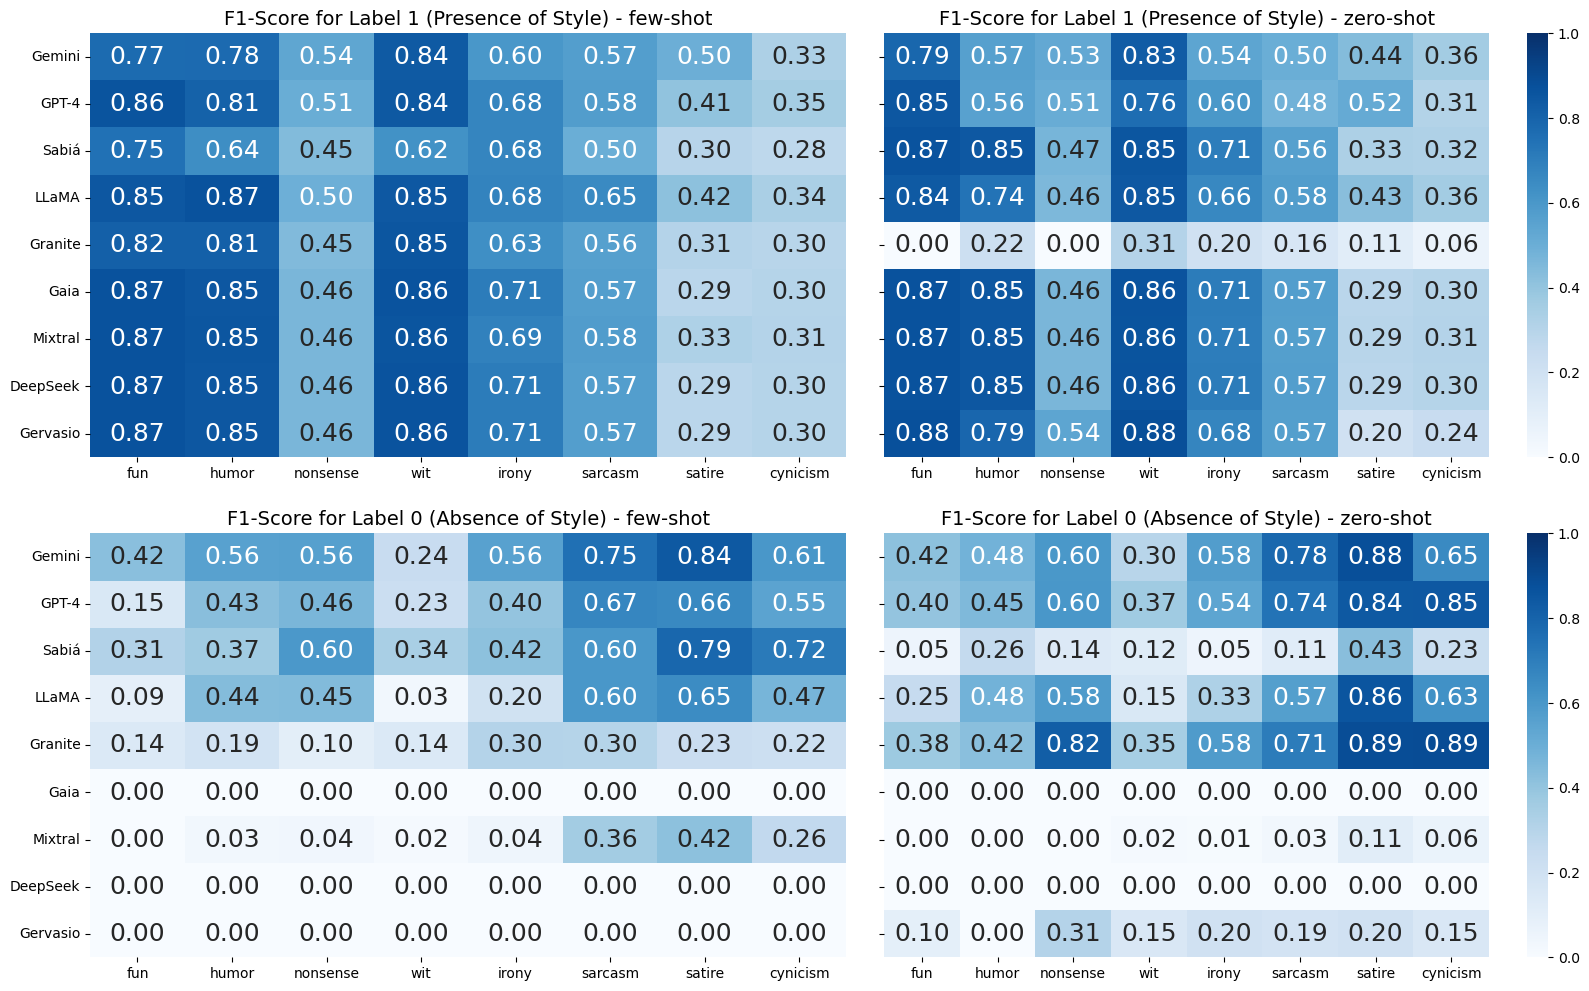

In [22]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), sharey=True)
f1_info = [('f1_1', 'Label 1 (Presence of Style)'), ('f1_0', 'Label 0 (Absence of Style)')]
scenarios = results['scenario'].unique()
style_order = ['fun', 'humor', 'nonsense', 'wit', 'irony', 'sarcasm', 'satire', 'cynicism']

for row_idx, (f1_class, title) in enumerate(f1_info):
    for col_idx, scenario in enumerate(scenarios):
        ax = axes[row_idx, col_idx]

        pivot = results[results['scenario'] == scenario].pivot_table(
            index='model_name', columns='comic_style', values=f1_class, aggfunc='mean'
        )
        
        pivot = pivot.reindex(columns=style_order)

        sns.heatmap(
            pivot,
            annot=True,
            cmap='Blues',
            vmin=0,
            vmax=1,
            ax=ax,
            fmt=".2f",
            annot_kws={'size': 18},
            cbar=(col_idx == 1)
        )
        
        ax.set_title(f'F1-Score for {title} - {scenario}', fontsize=14)
        ax.set_xlabel('', fontsize=16) 
        if col_idx == 0:
            ax.set_ylabel('', fontsize=16)
        else:
            ax.set_ylabel('')

        ax.tick_params(axis='x', labelsize=10, rotation=0)
        ax.tick_params(axis='y', labelsize=10)

plt.subplots_adjust(hspace=0.18, wspace=0.05)

plt.savefig(
    os.path.join(visus_path, "comic_styles_f1_individuals.png"), 
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [28]:
df_texts_explanations.columns

Index(['scenario', 'video_url', 'model_name', 'humorous_text', 'prompt',
       'model_text_explanation', 'annotated_text_explanation',
       'judge_model_results', 'agreement_level'],
      dtype='object')

In [17]:
comic_styles = df_comic_styles['comic_style'].unique()

print(comic_styles)

# O código abaixo cria dois dataframe de para cada estilo cômico, um de piores casos e outro de melhores. 
# Ex.: df_fun_worse, df_fun_better, df_irony_worse, df_irony_better.

for style in comic_styles:
    df_name_worse = f"df_{style}_worse"
    df_name_better = f"df_{style}_better"
    globals()[df_name_worse] = df_comic_styles[(df_comic_styles['comic_style'] == style) & (df_comic_styles['is_correct'] == 0)]
    globals()[df_name_better] = df_comic_styles[(df_comic_styles['comic_style'] == style) & (df_comic_styles['is_correct'] == 1)]

['fun' 'humor' 'nonsense' 'wit' 'irony' 'satire' 'sarcasm' 'cynicism']


##### Humor Reasoning

In [19]:
df_explanations_worse = df_texts_explanations[df_texts_explanations['agreement_level'] <= WORSE_EXPLANATIONS_THRESHOLD]
df_explanations_better = df_texts_explanations[df_texts_explanations['agreement_level'] >= BETTER_EXPLANATIONS_THRESHOLD]

In [20]:
expl_worse_summary = df_explanations_worse.groupby(['model_name', 'scenario']).agg({
    'agreement_level': ['count', 'mean']
}).round(3)

expl_worse_summary.columns = ['count', 'agreement_level']
expl_worse_summary = expl_worse_summary.reset_index()
expl_worse_summary = expl_worse_summary.sort_values(['model_name', 'scenario'])

print(expl_worse_summary)

                             model_name   scenario  count  agreement_level
0             deepseek-r1-0528-qwen3-8b   few-shot    359            1.471
1             deepseek-r1-0528-qwen3-8b  zero-shot    256            1.625
2                      gemini-2.5-flash   few-shot     70            1.886
3                      gemini-2.5-flash  zero-shot     31            1.871
4              gemma-3-gaia-pt-br-4b-it   few-shot    207            1.749
5              gemma-3-gaia-pt-br-4b-it  zero-shot    164            1.701
6   gervasio-7b-portuguese-ptbr-decoder   few-shot    430            1.300
7   gervasio-7b-portuguese-ptbr-decoder  zero-shot    435            1.186
8                                 gpt-4   few-shot     81            1.864
9                                 gpt-4  zero-shot     72            1.875
10              granite-3-3-8b-instruct   few-shot    161            1.739
11              granite-3-3-8b-instruct  zero-shot    147            1.789
12                       

In [21]:
expl_better_summary = df_explanations_better.groupby(['model_name', 'scenario']).agg({
    'agreement_level': ['count', 'mean']
}).round(3)

expl_better_summary.columns = ['count', 'agreement_level']
expl_better_summary = expl_better_summary.reset_index()
expl_better_summary = expl_better_summary.sort_values(['model_name', 'scenario'])

print(expl_better_summary)

                             model_name   scenario  count  agreement_level
0             deepseek-r1-0528-qwen3-8b   few-shot     92            4.413
1             deepseek-r1-0528-qwen3-8b  zero-shot    176            4.398
2                      gemini-2.5-flash   few-shot    398            4.756
3                      gemini-2.5-flash  zero-shot    433            4.875
4              gemma-3-gaia-pt-br-4b-it   few-shot    226            4.588
5              gemma-3-gaia-pt-br-4b-it  zero-shot    262            4.523
6   gervasio-7b-portuguese-ptbr-decoder   few-shot     37            4.486
7   gervasio-7b-portuguese-ptbr-decoder  zero-shot     29            4.517
8                                 gpt-4   few-shot    379            4.702
9                                 gpt-4  zero-shot    384            4.797
10              granite-3-3-8b-instruct   few-shot    284            4.623
11              granite-3-3-8b-instruct  zero-shot    295            4.637
12                       